In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

import time
import datetime

In [9]:
%matplotlib widget
plt.close("all")

In [10]:
LO_chain = np.load("results/bayes_samples_LO.npy")
NLO_chain = np.load("results/bayes_samples_NLO.npy")

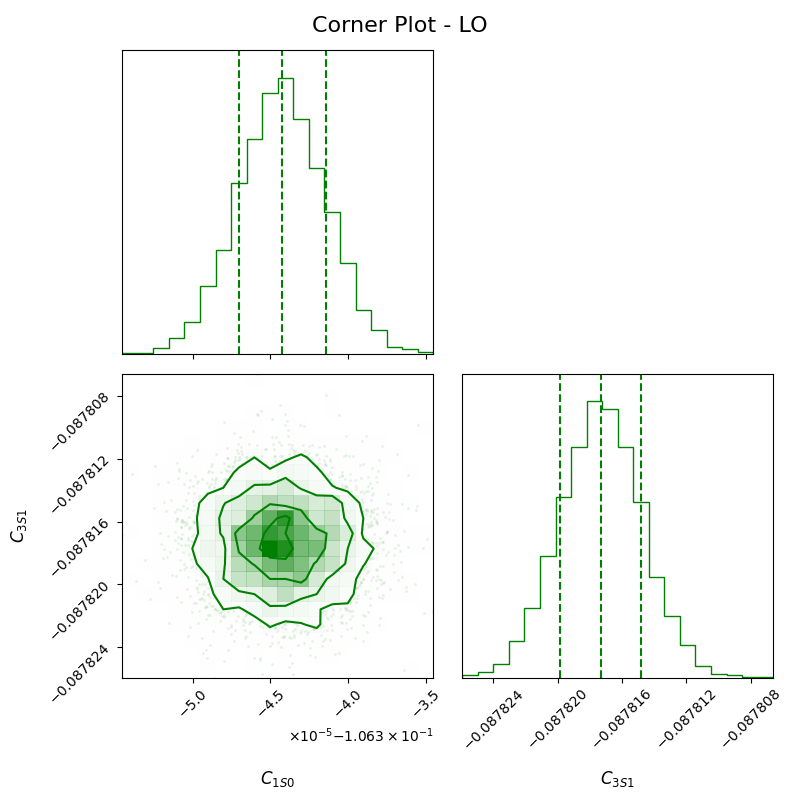

In [35]:
fig = plt.figure(figsize=(8, 8))


corner.corner(
    LO_chain, 
    labels=[r"$C_{1S0}$", r"$C_{3S1}$"], 
    show_titles=False,
    fig=fig, 
    color="green", 
    verbose=False,
    use_math_text=True,
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 12}
)

fig.suptitle("Corner Plot - LO", fontsize=16)
fig.tight_layout()

fig.savefig("figure/corner_LO.pdf", bbox_inches="tight")

plt.show()

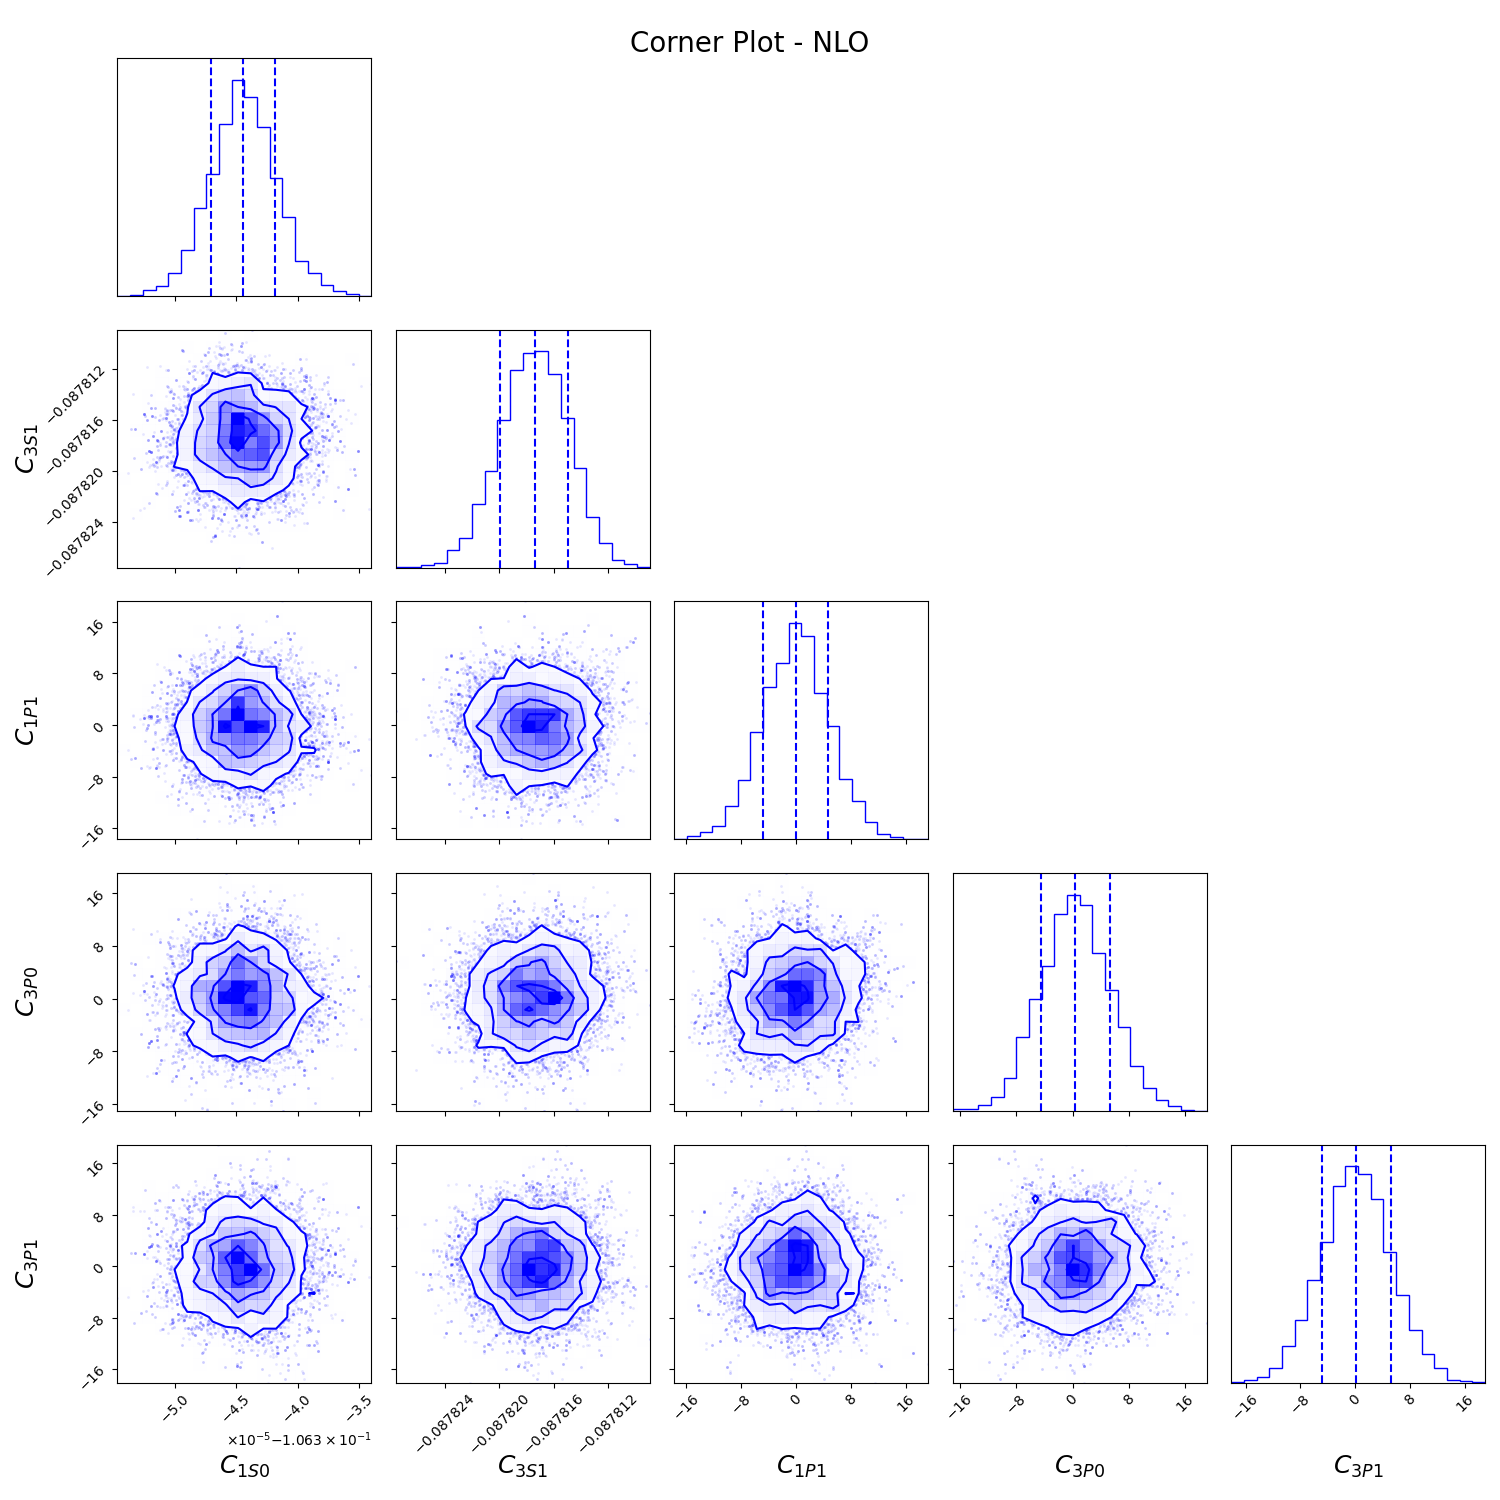

In [43]:
fig = plt.figure(figsize=(15, 15))


corner.corner(
    NLO_chain[int(0.5*len(NLO_chain)):], 
    labels=[r"$C_{1S0}$", r"$C_{3S1}$", r"$C_{1P1}$", r"$C_{3P0}$", r"$C_{3P1}$", r"$C_{3P2}$"], 
    show_titles=False,
    fig=fig, 
    color="blue", 
    verbose=False,
    use_math_text=True,
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 18}
)

fig.suptitle("Corner Plot - NLO", fontsize=20)
fig.tight_layout()

fig.savefig("figure/corner_NLO.pdf", bbox_inches="tight")

plt.show()

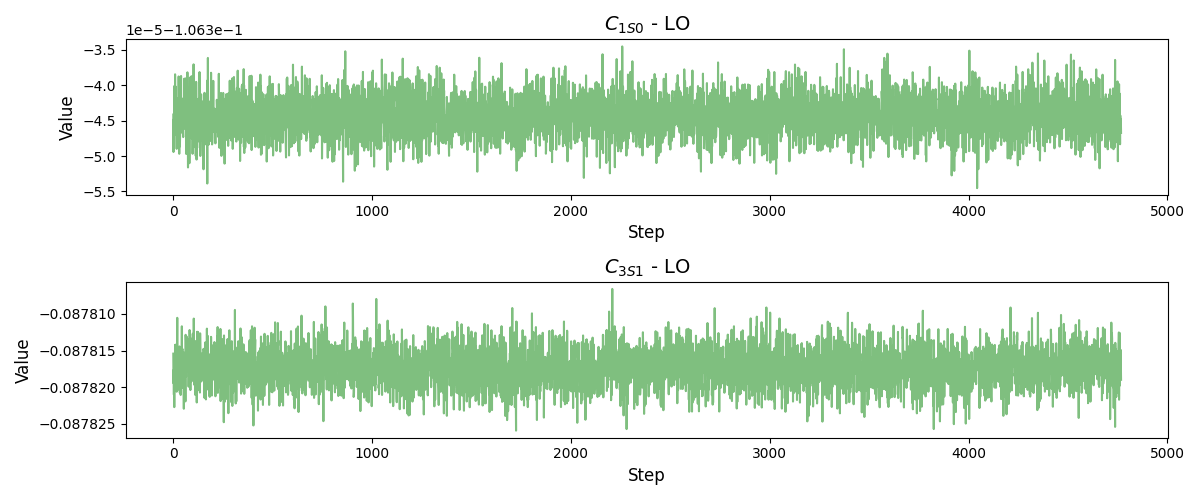

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

param1 = LO_chain[:, 0]
param2 = LO_chain[:, 1]

axes[0].plot(param1, color="green", alpha=0.5)
axes[0].set_title(r"$C_{1S0}$ - LO", fontsize=14)
axes[0].set_xlabel("Step", fontsize=12)
axes[0].set_ylabel("Value", fontsize=12)
axes[1].plot(param2, color="green", alpha=0.5)
axes[1].set_title(r"$C_{3S1}$ - LO", fontsize=14)
axes[1].set_xlabel("Step", fontsize=12)
axes[1].set_ylabel("Value", fontsize=12)
fig.tight_layout()
fig.savefig("figure/trace_LO.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_949554/1116151784.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(NLO_chain.shape[1], 1, figsize=(12, 20))


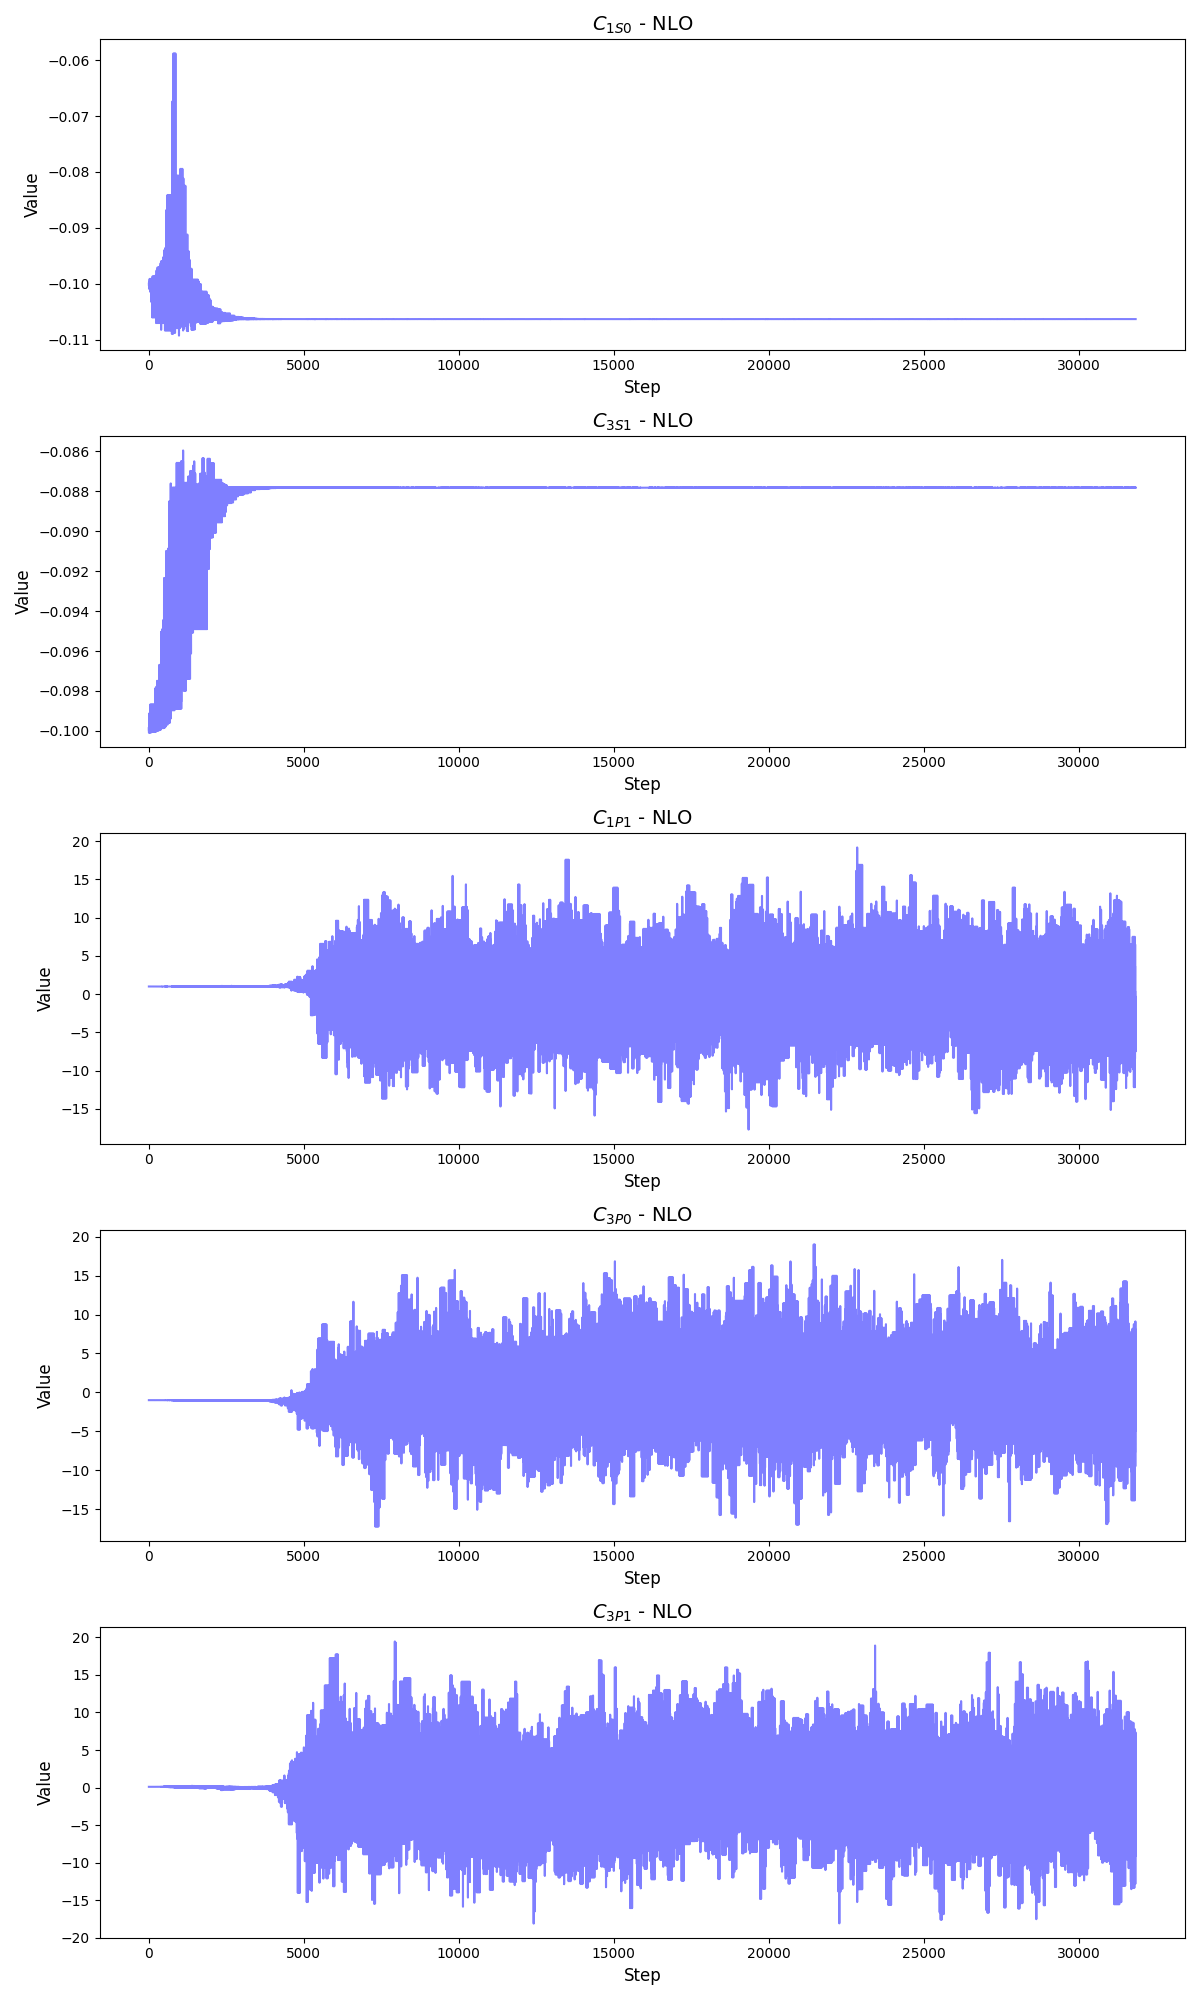

In [31]:
fig, axes = plt.subplots(NLO_chain.shape[1], 1, figsize=(12, 20))

params = [NLO_chain[:, i] for i in range(NLO_chain.shape[1])]
param_names = [r"$C_{1S0}$", r"$C_{3S1}$", r"$C_{1P1}$", r"$C_{3P0}$", r"$C_{3P1}$", r"$C_{3P2}$"]

for p, n in zip(params, param_names):
    idx = param_names.index(n)
    axes[idx].plot(p, color="blue", alpha=0.5)
    axes[idx].set_title(f"{n} - NLO", fontsize=14)
    axes[idx].set_xlabel("Step", fontsize=12)
    axes[idx].set_ylabel("Value", fontsize=12)
fig.tight_layout()
fig.savefig("figure/trace_NLO.pdf", bbox_inches="tight")
plt.show()